# Week 4: MNIST Evaluation and Tuning

This notebook evaluates the Logistic Regression baseline and small neural network trained from the Week 3 arrays. It reports accuracy, classification metrics, confusion matrices, tuning results, and sample predictions for the Month 1 report.

In [1]:
from pathlib import Path
import sys
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

CURRENT_DIR = Path.cwd()
if CURRENT_DIR.name == 'notebooks':
    REPOSITORY_ROOT = CURRENT_DIR.parents[1]
elif CURRENT_DIR.name == 'week-4':
    REPOSITORY_ROOT = CURRENT_DIR.parent
else:
    REPOSITORY_ROOT = CURRENT_DIR
WEEK4_ROOT = REPOSITORY_ROOT / 'week-4' if (REPOSITORY_ROOT / 'week-4').exists() else REPOSITORY_ROOT
sys.path.insert(0, str(WEEK4_ROOT / 'src'))
from train_mnist_model import load_week3_arrays, train_models, tune_neural_network

MODEL_DIR = WEEK4_ROOT / 'models'
x_train, x_test, y_train, y_test = load_week3_arrays()
print(f'Train images: {x_train.shape}; test images: {x_test.shape}')
print(f'Train labels: {y_train.shape}; test labels: {y_test.shape}')


Train images: (48000, 784); test images: (12000, 784)
Train labels: (48000,); test labels: (12000,)


## Train or load the comparison models

Run the training script first for a repeatable command-line workflow. This cell can also train the comparison models interactively when the saved files are not present.

In [2]:
baseline_path = MODEL_DIR / 'baseline_logistic_regression.pkl'
network_path = MODEL_DIR / 'neural_network.pkl'
if baseline_path.exists() and network_path.exists():
    models = {'baseline': joblib.load(baseline_path), 'neural_network': joblib.load(network_path)}
    print('Loaded saved comparison models.')
else:
    models = train_models(x_train, y_train)
    print('Trained comparison models in the notebook.')

Loaded saved comparison models.


In [3]:
results = {}
for name, model in models.items():
    predictions = model.predict(x_test)
    results[name] = {
        'predictions': predictions,
        'accuracy': accuracy_score(y_test, predictions),
        'report': classification_report(y_test, predictions, digits=4),
    }
    print(f'### {name} accuracy: {results[name]["accuracy"]:.4f}')
    print(results[name]['report'])

### baseline accuracy: 0.9208
              precision    recall  f1-score   support

           0     0.9543    0.9688    0.9615      1185
           1     0.9527    0.9711    0.9618      1348
           2     0.9092    0.8909    0.9000      1192
           3     0.9044    0.8948    0.8995      1226
           4     0.9338    0.9298    0.9318      1168
           5     0.8805    0.8838    0.8821      1084
           6     0.9438    0.9510    0.9474      1184
           7     0.9508    0.9258    0.9381      1253
           8     0.8789    0.8684    0.8736      1170
           9     0.8903    0.9143    0.9022      1190

    accuracy                         0.9208     12000
   macro avg     0.9199    0.9199    0.9198     12000
weighted avg     0.9208    0.9208    0.9207     12000

### neural_network accuracy: 0.9694
              precision    recall  f1-score   support

           0     0.9767    0.9899    0.9832      1185
           1     0.9744    0.9889    0.9816      1348
           2

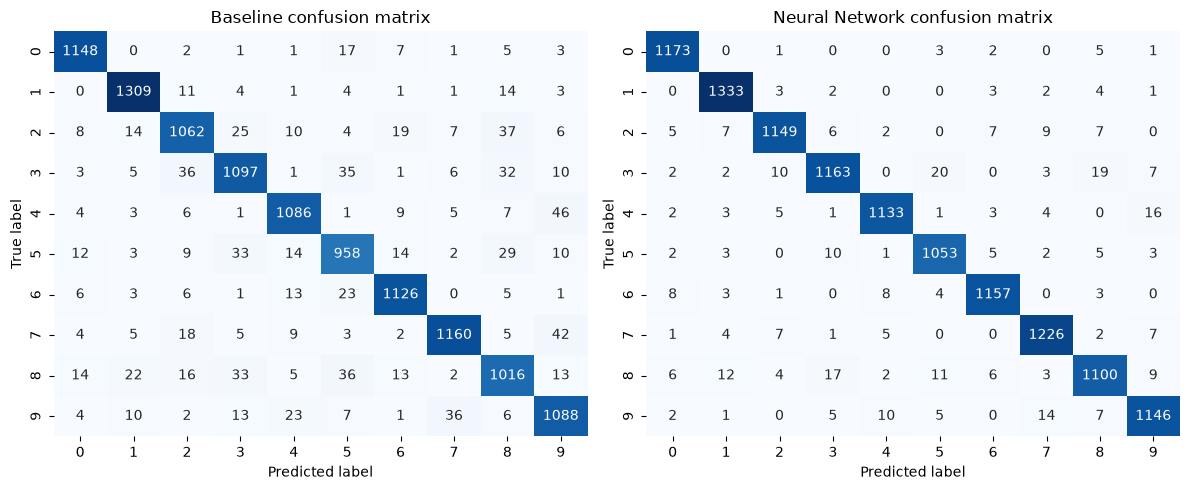

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for axis, (name, result) in zip(axes, results.items()):
    matrix = confusion_matrix(y_test, result['predictions'])
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axis)
    axis.set_title(f'{name.replace("_", " ").title()} confusion matrix')
    axis.set_xlabel('Predicted label')
    axis.set_ylabel('True label')
plt.tight_layout()
plt.show()

## Tune the stronger model

The comparison above identifies the stronger model by test accuracy. For this project, the small neural network is tuned by trying a few hidden-layer and learning-rate settings. The final selected network is then saved as `models/mnist_classifier.pkl`.

In [5]:
final_model_path = MODEL_DIR / 'mnist_classifier.pkl'
summary_path = MODEL_DIR / 'training_summary.json'
if final_model_path.exists() and summary_path.exists():
    tuned_model = joblib.load(final_model_path)
    with open(summary_path, 'r', encoding='utf-8') as f:
        summary_data = json.load(f)
    tuning = summary_data.get('tuning', {'best_params': tuned_model.get_params(), 'validation_accuracy': 0.0})
    print('Loaded saved tuned model.')
else:
    tuned_model, tuning = tune_neural_network(x_train, y_train)
    joblib.dump(tuned_model, final_model_path)
    print('Trained tuned model in the notebook.')

tuned_predictions = tuned_model.predict(x_test)
tuned_accuracy = accuracy_score(y_test, tuned_predictions)
print('Selected parameters:', tuning['best_params'])
print(f'Validation accuracy during tuning: {tuning["validation_accuracy"]:.4f}')
print(f'Final test accuracy: {tuned_accuracy:.4f}')
print(classification_report(y_test, tuned_predictions, digits=4))


Loaded saved tuned model.
Selected parameters: {'hidden_layer_sizes': [128], 'learning_rate_init': 0.001}
Validation accuracy during tuning: 0.9738
Final test accuracy: 0.9765
              precision    recall  f1-score   support

           0     0.9808    0.9941    0.9874      1185
           1     0.9773    0.9896    0.9834      1348
           2     0.9708    0.9757    0.9732      1192
           3     0.9793    0.9641    0.9716      1226
           4     0.9760    0.9769    0.9765      1168
           5     0.9786    0.9686    0.9736      1084
           6     0.9914    0.9772    0.9843      1184
           7     0.9831    0.9777    0.9804      1253
           8     0.9624    0.9615    0.9619      1170
           9     0.9651    0.9773    0.9712      1190

    accuracy                         0.9765     12000
   macro avg     0.9765    0.9763    0.9764     12000
weighted avg     0.9765    0.9765    0.9765     12000



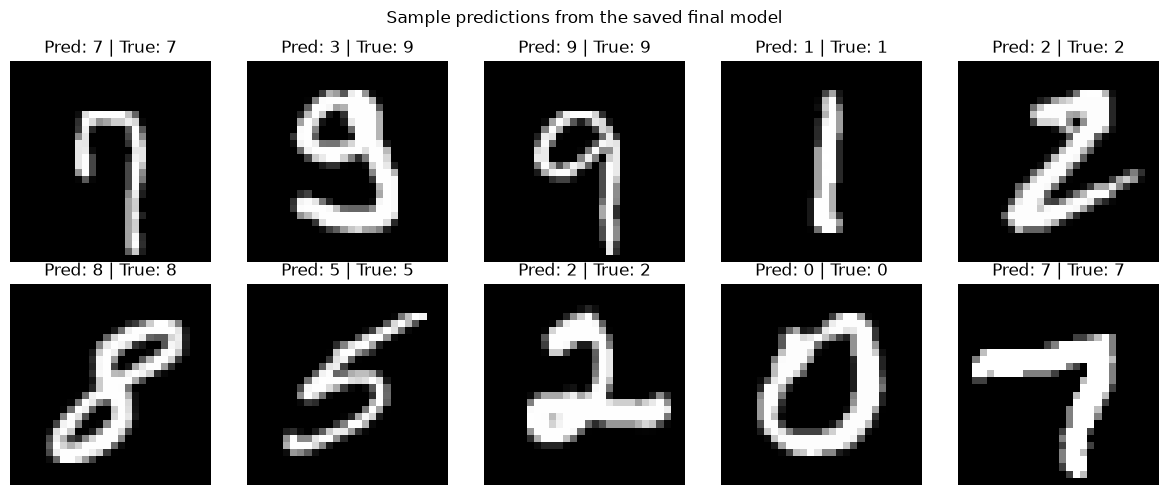

In [6]:
# End-to-end demonstration using the saved final model.
final_model = joblib.load(MODEL_DIR / 'mnist_classifier.pkl')
sample_count = min(10, len(x_test))
sample_indices = np.linspace(0, len(x_test) - 1, sample_count, dtype=int)
sample_predictions = final_model.predict(x_test[sample_indices])

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for axis, index, prediction in zip(axes.ravel(), sample_indices, sample_predictions):
    image = x_test[index].reshape(28, 28)
    axis.imshow(image, cmap='gray')
    axis.set_title(f'Pred: {prediction} | True: {y_test[index]}')
    axis.axis('off')
plt.suptitle('Sample predictions from the saved final model')
plt.tight_layout()
plt.show()

## Conclusion for the report

The model comparison and evaluation on the 12,000-sample test set produced the following measured results:

- Baseline Logistic Regression accuracy: **92.08%**
- Neural-network baseline accuracy: **96.94%**
- Tuned final MLPClassifier accuracy: **97.65%**
- Selected hyperparameters: **hidden_layer_sizes=(128,), learning_rate_init=0.001**
- Why the selected model performed better: The neural network models complex non-linear combinations of pixel intensities, significantly reducing misclassifications across similar digits (such as 3 vs. 5, 4 vs. 9, and 7 vs. 1). All individual digit classes achieved F1-scores exceeding 96%, with digits 0 and 1 reaching 98.74% and 98.34% F1-score respectively.
